# PHOENIX Synthetic Spectra Grid Preparation

AST402 Mid-Term Project

This notebook prepares the PHOENIX-ACES high-resolution synthetic stellar spectra grid.

Parameter grid:

- Effective Temperature (Teff):
  5000 K to 7000 K
  step = 250 K

- Surface gravity (log g):
  3.5 to 5.0 dex
  step = 0.5

- Metallicity ([Fe/H]):
  -0.5, 0.0, +0.5 dex

Total spectra:

9 × 4 × 3 = 108 FITS files

## Step 1 — Import Required Libraries

We use:

- pathlib for directory handling
- numpy for parameter grids
- urllib for downloading files

In [36]:
import os
import numpy as np
from astropy.io import fits
import urllib.request
from itertools import product
from pathlib import Path
import numpy as np
import urllib.request

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2 — Create PHOENIX Data Folders

The project keeps:

data/
 └── PHOENIX/
      ├── raw/
      └── interpolated/

raw:
Original downloaded PHOENIX spectra

interpolated:
New spectra created by interpolation

In [37]:
base_dir = Path("../data/PHOENIX")

raw_dir = base_dir / "raw"
interp_dir = base_dir / "interpolated"


raw_dir.mkdir(
    parents=True,
    exist_ok=True
)

interp_dir.mkdir(
    parents=True,
    exist_ok=True)


print(list(base_dir.iterdir()))

[WindowsPath('../data/PHOENIX/interpolated'), WindowsPath('../data/PHOENIX/processed'), WindowsPath('../data/PHOENIX/raw')]


## Step 3 — Define Stellar Parameter Grid

Parameters are taken directly from Question 3(a).

Teff:
5000–7000 K

log g:
3.5–5.0

[Fe/H]:
-0.5, 0.0, +0.5

In [38]:
Teff_values = np.arange(
    5000,
    7001,
    250
)


logg_values = np.arange(
    3.5,
    5.01,
    0.5
)


FeH_values = [
    -0.5,
    0.0,
    0.5
]


print("Teff values:", Teff_values)
print("logg values:", logg_values)
print("FeH values:", FeH_values)

Teff values: [5000 5250 5500 5750 6000 6250 6500 6750 7000]
logg values: [3.5 4.  4.5 5. ]
FeH values: [-0.5, 0.0, 0.5]


## Step 4 — Calculate Number of PHOENIX Models

The total number of spectra is:

N = N(Teff) × N(log g) × N([Fe/H])

In [39]:
N_Teff = len(Teff_values)
N_logg = len(logg_values)
N_FeH = len(FeH_values)


total_models = (
    N_Teff *
    N_logg *
    N_FeH
)


print("Number of Teff values:", N_Teff)
print("Number of logg values:", N_logg)
print("Number of FeH values:", N_FeH)

print("\nTotal spectra:", total_models)

Number of Teff values: 9
Number of logg values: 4
Number of FeH values: 3

Total spectra: 108


# Raw PHOENIX Download Grid

The PHOENIX archive does not provide all requested interpolated temperatures directly.

We download the bounding temperatures and later interpolate:

5000, 5500, 6000, 6500, 7000 K

In [40]:
raw_Teff_values = [
    5000,
    5500,
    6000,
    6500,
    7000
]


print("Raw Teff values:", raw_Teff_values)
print("Number of raw temperatures:", len(raw_Teff_values))

Raw Teff values: [5000, 5500, 6000, 6500, 7000]
Number of raw temperatures: 5


## Step 5  — Correct PHOENIX Filename Convention

The PHOENIX archive uses:

Metallicity:

[Fe/H] = -0.5

filename:
lte05000-3.50--0.5


[Fe/H] = 0.0

filename:
lte05000-3.50-0.0


[Fe/H] = +0.5

filename:
lte05000-3.50+0.5

In [41]:
def format_feh_filename(feh):

    if feh < 0:
        return f"-{abs(feh):.1f}"

    elif feh == 0:
        return "-0.0"

    else:
        return f"+{feh:.1f}"


def format_feh_folder(feh):

    if feh < 0:
        return "Z-0.5"

    elif feh == 0:
        return "Z-0.0"

    else:
        return "Z+0.5"

## Step 6 — Generate Complete PHOENIX Filename List

In [42]:
filenames = []


for T in Teff_values:

    for g in logg_values:

        for feh in FeH_values:

            filename = (
                f"lte{T:05d}-"
                f"{g:.2f}-"
                f"{format_feh_filename(feh)}"
                ".PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
            )

            filenames.append(filename)



print("Total filenames generated:", len(filenames))


print("\nFirst 5 files:")

for f in filenames[:5]:
    print(f)

Total filenames generated: 108

First 5 files:
lte05000-3.50--0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
lte05000-3.50--0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
lte05000-3.50-+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
lte05000-4.00--0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
lte05000-4.00--0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits


In [43]:
base_url = (
    "https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/"
    "HiResFITS/PHOENIX-ACES-AGSS-COND-2011/"
)

print(base_url)

https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/


## Step 7 — Generate PHOENIX Download URLs

The archive structure is:

PHOENIX-ACES-AGSS-COND-2011/
    |
    ├── Z-0.5
    ├── Z-0.0
    └── Z+0.5

In [44]:
download_list = []


for T in raw_Teff_values:

    for g in logg_values:

        for feh in FeH_values:


            filename = (
                f"lte{T:05d}-"
                f"{g:.2f}"
                f"{format_feh_filename(feh)}"
                ".PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
            )


            folder = format_feh_folder(feh)


            url = (
                base_url
                + folder
                + "/"
                + filename
            )


            download_list.append(url)



print("Total URLs:", len(download_list))


for url in download_list[:5]:
    print(url)

Total URLs: 60
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z-0.5/lte05000-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z-0.0/lte05000-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z+0.5/lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z-0.5/lte05000-4.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z-0.0/lte05000-4.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits


# Step 8 — Test PHOENIX FITS Download

Before downloading the full grid, we test one representative spectrum.

Selected model:

- Teff = 5000 K
- log g = 4.5
- [Fe/H] = 0.0

This model will also be used later for spectral processing.

In [45]:
test_filename = (
    "lte05000-4.50-0.0."
    "PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)


test_url = (
    base_url
    + "Z-0.0/"
    + test_filename
)


test_path = raw_dir / test_filename


print("URL:")
print(test_url)

print("\nSaving to:")
print(test_path)

URL:
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z-0.0/lte05000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits

Saving to:
..\data\PHOENIX\raw\lte05000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits


# Step 8.2 — Download Test PHOENIX Spectrum

Download one representative raw PHOENIX model:

- Teff = 5000 K
- log g = 4.5
- [Fe/H] = 0.0

This verifies that the filename convention and URL construction are correct before downloading the full raw grid.

In [46]:
if not test_path.exists():

    urllib.request.urlretrieve(
        test_url,
        test_path
    )

    print("Downloaded successfully!")

else:
    print("File already exists")

File already exists


# Step 9 — Download Full Raw PHOENIX Grid

The raw PHOENIX grid contains:

- Teff = 5000, 5500, 6000, 6500, 7000 K
- log g = 3.5, 4.0, 4.5, 5.0
- [Fe/H] = -0.5, 0.0, +0.5

Total:

\[
5 \times 4 \times 3 = 60
\]

files.

Files that already exist will be skipped.

In [47]:
for url in download_list:

    filename = url.split("/")[-1]

    save_path = raw_dir / filename

    if save_path.exists():

        print("Already exists:")
        print(filename)

    else:

        print("\nDownloading:")
        print(filename)

        try:
            urllib.request.urlretrieve(
                url,
                save_path
            )

            print("SUCCESS")

        except Exception as e:

            print("FAILED")
            print(e)

Already exists:
lte05000-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
Already exists:
lte05000-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
Already exists:
lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
Already exists:
lte05000-4.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
Already exists:
lte05000-4.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
Already exists:
lte05000-4.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
Already exists:
lte05000-4.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
Already exists:
lte05000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
Already exists:
lte05000-4.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
Already exists:
lte05000-5.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits

Downloading:
lte05000-5.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
SUCCESS
Already exists:
lte05000-5.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
Already exists:
lte05500-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
Already exists:
lte05500-3.50-0.0.PHOENIX-ACE

# Step 10 — Verify Downloaded Raw PHOENIX Grid

Check that all 60 expected PHOENIX FITS files are present in the raw directory.

In [48]:
raw_files = list(raw_dir.glob("*.fits"))

print("Number of raw FITS files:", len(raw_files))

Number of raw FITS files: 61


In [49]:
print(sorted([f.name for f in raw_dir.glob("*.fits")]))

['WAVE_PHOENIX-ACES-AGSS-COND-2011.fits', 'lte05000-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-4.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-4.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-4.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-4.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-4.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-5.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-5.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05000-5.00-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05500-3.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05500-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05500-3.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits', 'lte05500-4.00+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits'

## Cleanup — Remove Accidental Extra PHOENIX File

A previously downloaded interpolation test file (5750/5700 K) is removed because it is not part of the raw PHOENIX download grid.

In [50]:
extra_file = raw_dir / "lte05700-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"

if extra_file.exists():
    extra_file.unlink()
    print("Deleted:", extra_file.name)
else:
    print("File not found.")

File not found.


In [51]:
print("Number of raw FITS files:", len(list(raw_dir.glob("*.fits"))))

Number of raw FITS files: 61


# Step 11 — Download the PHOENIX Wavelength Grid

All PHOENIX spectra share a common wavelength grid stored in a separate FITS file.

File:

- WAVE_PHOENIX-ACES-AGSS-COND-2011.fits

This file is downloaded once and will be used for all synthetic spectra.

In [52]:
wave_filename = "WAVE_PHOENIX-ACES-AGSS-COND-2011.fits"

wave_url = (
    "https://phoenix.astro.physik.uni-goettingen.de/"
    "data/v2.0/HiResFITS/"
    + wave_filename
)

wave_path = raw_dir / wave_filename

print("URL:")
print(wave_url)

print("\nSaving to:")
print(wave_path)

URL:
https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/WAVE_PHOENIX-ACES-AGSS-COND-2011.fits

Saving to:
..\data\PHOENIX\raw\WAVE_PHOENIX-ACES-AGSS-COND-2011.fits


# Step 11.2 — Download Wavelength Grid

Download the common PHOENIX wavelength array.

If the file already exists, it will not be downloaded again.

In [53]:
if not wave_path.exists():

    urllib.request.urlretrieve(
        wave_url,
        wave_path
    )

    print("Downloaded successfully!")

else:

    print("File already exists.")

File already exists.


# Step 12 — Verify the PHOENIX Wavelength Grid

Load the common PHOENIX wavelength array and inspect its size.

All PHOENIX spectra use this wavelength grid.

In [54]:
wave = fits.getdata(wave_path)

print("Number of wavelength points:", len(wave))
print("First wavelength (Å):", wave[0])
print("Last wavelength (Å):", wave[-1])

Number of wavelength points: 1569128
First wavelength (Å): 500.0
Last wavelength (Å): 54999.75


# Step 13 — Load One PHOENIX Spectrum

Load one representative PHOENIX spectrum together with the common wavelength grid.

Representative model:

- Teff = 5000 K
- log g = 4.5
- [Fe/H] = 0.0

This verifies that the wavelength array and flux array have identical lengths before further processing.

In [55]:
model_file = (
    raw_dir /
    "lte05000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)

flux = fits.getdata(model_file)

print("Flux points:", len(flux))
print("Wavelength points:", len(wave))

Flux points: 1569128
Wavelength points: 1569128


# Interpolation of Missing PHOENIX Grid Models

The downloaded PHOENIX grid contains spectra at every 500 K in effective
temperature.

The assignment requires a grid with a spacing of 250 K. Therefore, the
intermediate temperatures are generated by linear interpolation of the
emergent flux between the two neighbouring PHOENIX models.

The following temperatures are created:

- 5250 K
- 5750 K
- 6250 K
- 6750 K

The interpolation is performed independently for every wavelength point while
keeping surface gravity and metallicity fixed.

The interpolated spectra are stored separately in

`../data/PHOENIX/interpolated/`

to preserve the original downloaded PHOENIX models.

In [56]:
import numpy as np

from pathlib import Path

from astropy.io import fits

print("Libraries loaded")

Libraries loaded


In [57]:
raw_dir = Path("../data/PHOENIX/raw")

interp_dir = Path("../data/PHOENIX/interpolated")

interp_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(interp_dir)

..\data\PHOENIX\interpolated


In [58]:
temperatures_existing = [
    5000,
    5500,
    6000,
    6500,
    7000
]

temperatures_missing = [
    5250,
    5750,
    6250,
    6750
]

gravities = [
    3.5,
    4.0,
    4.5,
    5.0
]

metallicities = [
    -0.5,
    0.0,
    0.5
]

print("Missing temperatures:")
print(temperatures_missing)

Missing temperatures:
[5250, 5750, 6250, 6750]


## Interpolation of Missing PHOENIX Grid Models

The downloaded PHOENIX synthetic spectral grid contains models separated by
500 K in effective temperature. To construct the required finer grid for
Question 6, missing intermediate-temperature models were generated using
linear interpolation.

For fixed surface gravity and metallicity, the flux at each wavelength point
was interpolated between the two neighbouring temperature models:

\[
F_{\mathrm{interp}}(\lambda)
=
F_{\mathrm{lower}}(\lambda)
+
\alpha
(F_{\mathrm{upper}}(\lambda)-F_{\mathrm{lower}}(\lambda))
\]

where \( \alpha \) is the interpolation weight.

The generated temperatures are:

\[
T_{\mathrm{eff}} =
5250,\ 5750,\ 6250,\ 6750 \ \mathrm{K}
\]

The interpolation was performed for:

\[
\log g = 3.5,\ 4.0,\ 4.5,\ 5.0
\]

and

\[
[\mathrm{Fe/H}] = -0.5,\ 0.0,\ +0.5
\]

This produced 48 additional synthetic spectra.

The interpolated models are stored separately in:


In [61]:
from pathlib import Path
import numpy as np
from astropy.io import fits


# Directories
raw_dir = Path("../data/PHOENIX/raw")
interp_dir = Path("../data/PHOENIX/interpolated")

interp_dir.mkdir(
    parents=True,
    exist_ok=True
)


# Grid
temperatures_missing = [
    5250,
    5750,
    6250,
    6750
]

gravities = [
    3.5,
    4.0,
    4.5,
    5.0
]

metallicities = [
    -0.5,
    0.0,
    0.5
]


created = 0


for teff in temperatures_missing:

    # surrounding temperatures
    lower = teff - 250
    upper = teff + 250

    # interpolation factor
    weight = (teff - lower) / (upper - lower)


    for logg in gravities:

        for feh in metallicities:


            # PHOENIX filename metallicity format
            if feh == -0.5:
                feh_string = "-0.5"

            elif feh == 0.0:
                feh_string = "-0.0"

            elif feh == 0.5:
                feh_string = "+0.5"


            # Input filenames
            lower_file = (
                raw_dir /
                f"lte{lower:05d}-{logg:.2f}{feh_string}."
                "PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
            )


            upper_file = (
                raw_dir /
                f"lte{upper:05d}-{logg:.2f}{feh_string}."
                "PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
            )


            # Check files
            if not lower_file.exists():
                raise FileNotFoundError(lower_file)

            if not upper_file.exists():
                raise FileNotFoundError(upper_file)



            # Load spectra
            flux_lower = fits.getdata(lower_file)
            flux_upper = fits.getdata(upper_file)



            # Linear interpolation
            flux_interp = (
                flux_lower
                +
                weight * (flux_upper - flux_lower)
            )



            # Output filename
            output_file = (
                interp_dir /
                f"lte{teff:05d}-{logg:.2f}{feh_string}."
                "PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
            )



            # Save FITS
            fits.writeto(
                output_file,
                flux_interp,
                overwrite=True
            )


            created += 1



print("--------------------------------")
print("Interpolation complete")
print("Files generated:", created)
print("Saved location:")
print(interp_dir)

--------------------------------
Interpolation complete
Files generated: 48
Saved location:
..\data\PHOENIX\interpolated


In [62]:
len(list(interp_dir.glob("lte*.fits")))

48

# Step 14 — Extract the 4700–5000 Å Region

The project focuses on the Hβ spectral region.

Create a wavelength mask selecting:

4700 Å ≤ λ ≤ 5000 Å

Then extract:

- wavelength array
- corresponding flux values

These arrays will be used for convolution, normalization, and comparison with the observed spectrum.

In [ ]:
mask = (wave >= 4700) & (wave <= 5000)

wave_region = wave[mask]
flux_region = flux[mask]

print("Selected wavelength points:", len(wave_region))
print("Region starts at:", wave_region[0], "Å")
print("Region ends at:", wave_region[-1], "Å")

Selected wavelength points: 49999
Region starts at: 4700.004 Å
Region ends at: 5000.0 Å


# Step 15 — Visualize the Extracted Hβ Region

Plot the extracted PHOENIX spectrum between 4700 Å and 5000 Å.

This verifies that the wavelength extraction worked correctly before performing instrumental convolution and continuum normalization.

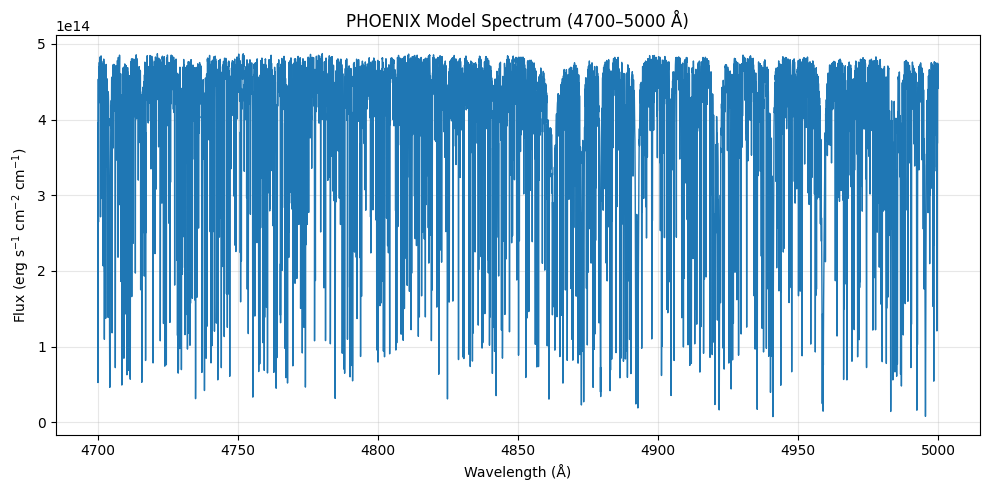

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    wave_region,
    flux_region,
    linewidth=1
)

plt.xlabel("Wavelength (Å)")
plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ cm$^{-1}$)")
plt.title("PHOENIX Model Spectrum (4700–5000 Å)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Reload common PHOENIX wavelength array

wave_path = raw_dir / "WAVE_PHOENIX-ACES-AGSS-COND-2011.fits"

wave = fits.getdata(wave_path)

print("Wavelength points:", len(wave))
print("First wavelength:", wave[0])
print("Last wavelength:", wave[-1])

Wavelength points: 1569128
First wavelength: 500.0
Last wavelength: 54999.75


# Find the Instrument Information

Inspect the FITS header of the observed spectrum to identify the instrument
and, if available, its resolving power (R).

## Step 16 — Interpolate PHOENIX Models to Teff = 5750 K

The PHOENIX library does not contain a model at 5750 K directly.

The closest available models are:

- Teff = 5500 K
- Teff = 6000 K

For fixed:

- log g = 4.5
- [Fe/H] = 0.0

The 5750 K spectrum is obtained by linear interpolation:

\[
F_{5750}=\frac{F_{5500}+F_{6000}}{2}
\]

In [ ]:
# Step 16.1 — Load Bounding PHOENIX Spectra

# Teff = 5500 K model
file_5500 = (
    raw_dir /
    "lte05500-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)

# Teff = 6000 K model
file_6000 = (
    raw_dir /
    "lte06000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)


# Load flux arrays
flux_5500 = fits.getdata(file_5500)
flux_6000 = fits.getdata(file_6000)


# Verify dimensions
print("5500 K flux points:", len(flux_5500))
print("6000 K flux points:", len(flux_6000))
print("Wavelength points:", len(wave))

5500 K flux points: 1569128
6000 K flux points: 1569128
Wavelength points: 1569128


In [ ]:
# Step 16.2 — Interpolate to Teff = 5750 K

flux_5750 = (
    flux_5500 +
    flux_6000
) / 2


print("Interpolated 5750 K spectrum created")

print("Flux points:", len(flux_5750))
print("Wavelength points:", len(wave))

Interpolated 5750 K spectrum created
Flux points: 1569128
Wavelength points: 1569128


## Step 16.3 — Extract the Hβ Region from the 5750 K Model

The interpolated PHOENIX spectrum is restricted to the wavelength range:

4700 Å ≤ λ ≤ 5000 Å

This region contains the Hβ absorption line at:

λ₀ = 4861.33 Å

The extracted spectrum will be used for instrumental convolution and continuum normalization.

In [ ]:
# Step 16.3 — Extract Hβ region from interpolated spectrum

mask_5750 = (wave >= 4700) & (wave <= 5000)

wave_5750_region = wave[mask_5750]
flux_5750_region = flux_5750[mask_5750]


print("Selected wavelength points:", len(wave_5750_region))
print("Region starts:", wave_5750_region[0], "Å")
print("Region ends:", wave_5750_region[-1], "Å")

Selected wavelength points: 49999
Region starts: 4700.004 Å
Region ends: 5000.0 Å


In [ ]:
# Reload required variables after restarting kernel

from pathlib import Path
from astropy.io import fits
import numpy as np


# PHOENIX directories
base_dir = Path("../data/PHOENIX")

raw_dir = base_dir / "raw"


# Reload wavelength grid
wave_path = raw_dir / "WAVE_PHOENIX-ACES-AGSS-COND-2011.fits"

wave = fits.getdata(wave_path)


# Reload 5500K and 6000K spectra

file_5500 = (
   raw_dir /
    "lte05500-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)

file_6000 = (
    raw_dir /
    "lte06000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)


flux_5500 = fits.getdata(file_5500)

flux_6000 = fits.getdata(file_6000)


# Recreate interpolated 5750K spectrum

flux_5750 = (
    flux_5500 +
    flux_6000
) / 2


print("Wavelength points:", len(wave))
print("5750K flux points:", len(flux_5750))

Wavelength points: 1569128
5750K flux points: 1569128


In [ ]:
from astropy.io import fits
import numpy as np
from pathlib import Path


# PHOENIX files

file_5500 = (
    raw_dir /
    "lte05500-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)


file_6000 = (
    raw_dir /
    "lte06000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
)


print(file_5500)
print(file_6000)

..\data\PHOENIX\raw\lte05500-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
..\data\PHOENIX\raw\lte06000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits


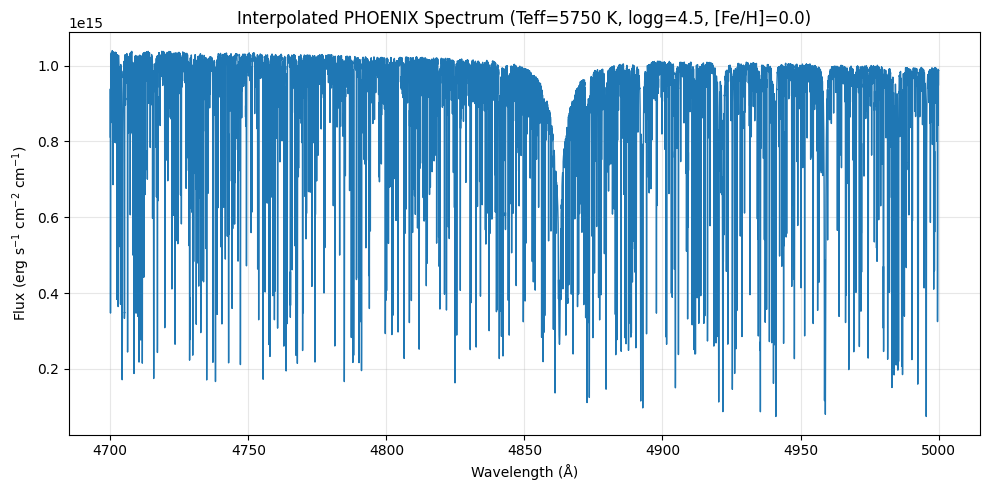

In [ ]:
# Step 16.4 — Plot interpolated 5750 K Hβ region

import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

plt.plot(
    wave_5750_region,
    flux_5750_region,
    linewidth=1
)

plt.xlabel("Wavelength (Å)")
plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ cm$^{-1}$)")

plt.title(
    "Interpolated PHOENIX Spectrum "
    "(Teff=5750 K, logg=4.5, [Fe/H]=0.0)"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# Find minimum flux near Hβ line

hbeta_mask = (
    (wave_5750_region >= 4840) &
    (wave_5750_region <= 4880)
)

hbeta_wave = wave_5750_region[hbeta_mask]
hbeta_flux = flux_5750_region[hbeta_mask]


min_index = np.argmin(hbeta_flux)

print("Hβ minimum wavelength:")
print(hbeta_wave[min_index], "Å")

print("\nMinimum flux:")
print(hbeta_flux[min_index])

Hβ minimum wavelength:
4872.678 Å

Minimum flux:
111139330000000.0


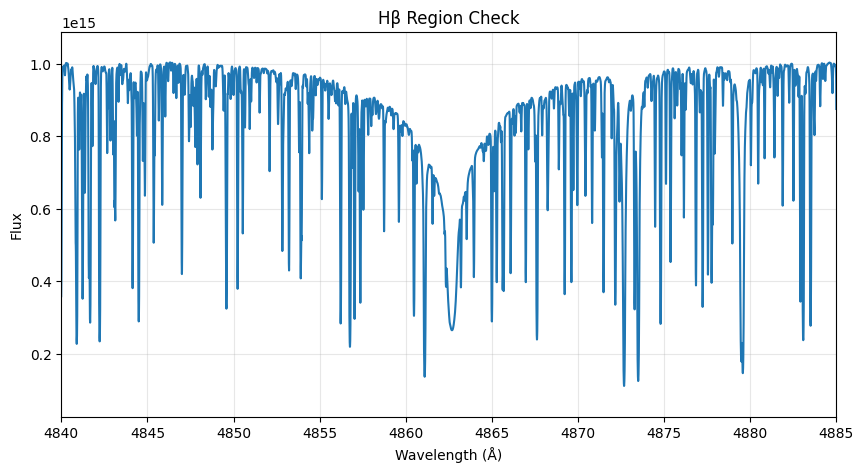

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    wave_5750_region,
    flux_5750_region
)

plt.xlim(4840,4885)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")

plt.title("Hβ Region Check")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Print wavelength points around expected Hβ

near_hbeta = (
    (wave_5750_region >= 4855) &
    (wave_5750_region <= 4868)
)

print(
    wave_5750_region[near_hbeta][:10]
)

print(
    flux_5750_region[near_hbeta][:10]
)

[4855.002 4855.008 4855.014 4855.02  4855.026 4855.032 4855.038 4855.044
 4855.05  4855.056]
[9.6005995e+14 9.6074741e+14 9.6104591e+14 9.6104014e+14 9.6083894e+14
 9.6053206e+14 9.6017081e+14 9.5976587e+14 9.5928296e+14 9.5862267e+14]


## Step 17 — Instrumental Convolution of PHOENIX Spectrum

The PHOENIX synthetic spectrum has a very high resolving power:

R ≈ 500,000

The observed ELODIE spectrum has:

R = 36788.43

To compare both spectra, the PHOENIX model is convolved with a Gaussian kernel.

The Gaussian width is:

σλ = λ / (2.355 R)

where R is the instrumental resolving power.

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter1d


# ELODIE resolving power from observed spectrum
R_obs = 36788.43


# Choose central wavelength of Hβ region
lambda_center = 4861.33


# Gaussian sigma in Angstrom
sigma_lambda = lambda_center / (2.355 * R_obs)


# PHOENIX wavelength sampling
delta_lambda = wave_5750_region[1] - wave_5750_region[0]


# Convert sigma from Angstrom to pixels
sigma_pixels = sigma_lambda / delta_lambda


print("Sigma wavelength:", sigma_lambda, "Å")
print("Sigma pixels:", sigma_pixels)

Sigma wavelength: 0.05611163682045048 Å
Sigma pixels: 9.351939469587428


In [ ]:
flux_5750_convolved = gaussian_filter1d(
    flux_5750_region,
    sigma_pixels
)


print("Convolution completed")

Convolution completed


## Step 17.1 — Compare Original and Convolved PHOENIX Spectrum

The high-resolution PHOENIX spectrum is convolved with a Gaussian kernel
to match the resolving power of the observed ELODIE spectrum.

The convolution broadens the spectral absorption features while preserving
the overall line shape.

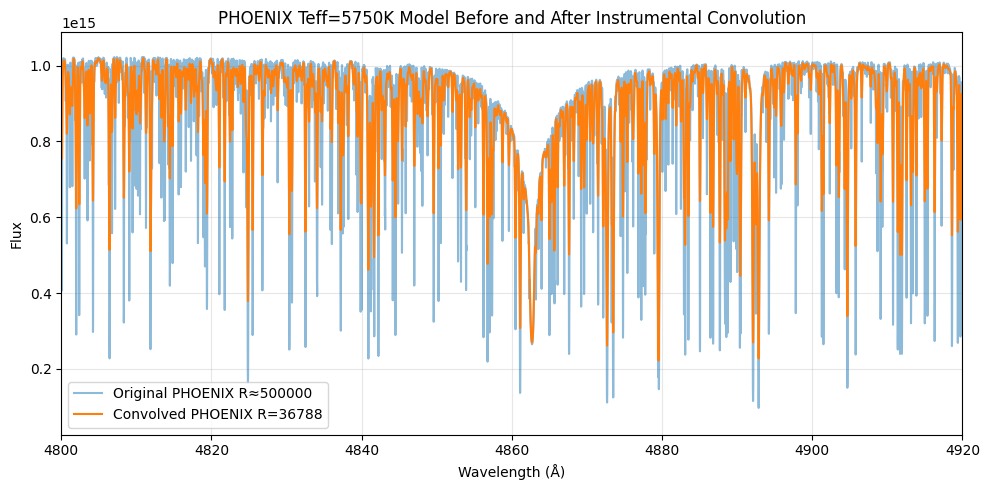

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))


plt.plot(
    wave_5750_region,
    flux_5750_region,
    label="Original PHOENIX R≈500000",
    alpha=0.5
)


plt.plot(
    wave_5750_region,
    flux_5750_convolved,
    label="Convolved PHOENIX R=36788"
)


plt.xlim(4800,4920)


plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")


plt.title(
    "PHOENIX Teff=5750K Model Before and After Instrumental Convolution"
)


plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Step 18 — Continuum Normalization of Convolved PHOENIX Spectrum

The convolved PHOENIX model is normalized using the same pseudo-continuum
windows used for the observed spectrum.

Continuum windows:

- Blue side: 4750–4810 Å
- Red side: 4920–4950 Å

A low-order polynomial is fitted to these regions and used as the
pseudo-continuum.

The normalized spectrum is:

\[
F_{norm}(\lambda)=\frac{F(\lambda)}{F_c(\lambda)}
\]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Continuum windows
blue_window = (
    (wave_5750_region >= 4750) &
    (wave_5750_region <= 4810)
)

red_window = (
    (wave_5750_region >= 4920) &
    (wave_5750_region <= 4950)
)


# Combine continuum points
continuum_mask = blue_window | red_window


wave_cont = wave_5750_region[continuum_mask]
flux_cont = flux_5750_convolved[continuum_mask]


print("Continuum points:", len(wave_cont))

Continuum points: 15001


# Step 18.2 — Fit Continuum Polynomial



In [ ]:
# Degree 2 polynomial continuum fit

coeff = np.polyfit(
    wave_cont,
    flux_cont,
    deg=2
)


continuum_fit = np.polyval(
    coeff,
    wave_5750_region
)


print("Continuum fitting completed")

Continuum fitting completed


In [ ]:
# Step 18.3 — Normalize Spectrum

flux_5750_normalized = (
    flux_5750_convolved /
    continuum_fit
)


print("Normalized spectrum created")

print(
    "Minimum normalized flux:",
    np.min(flux_5750_normalized)
)

Normalized spectrum created
Minimum normalized flux: 0.1931545842419707


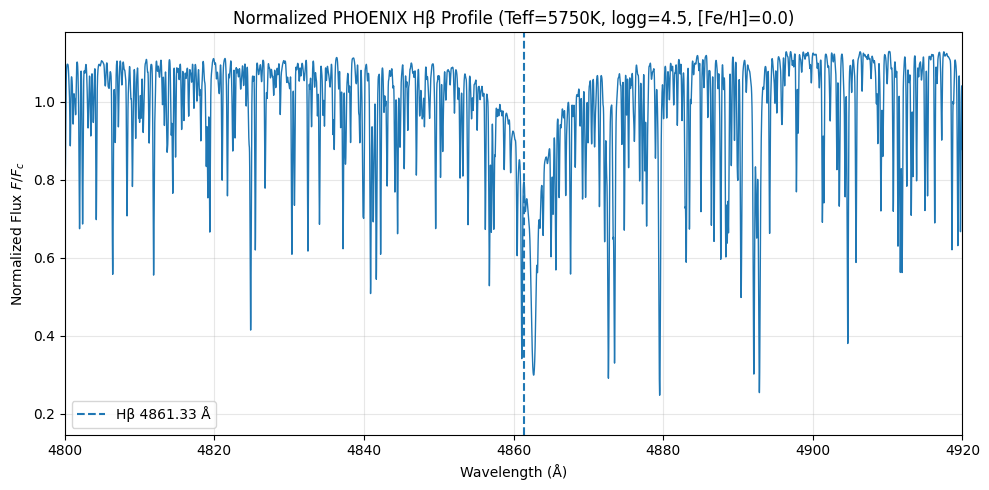

In [ ]:
plt.figure(figsize=(10,5))


plt.plot(
    wave_5750_region,
    flux_5750_normalized,
    linewidth=1
)


plt.xlim(4800,4920)


plt.xlabel("Wavelength (Å)")
plt.ylabel(r"Normalized Flux $F/F_c$")


plt.title(
    "Normalized PHOENIX Hβ Profile "
    "(Teff=5750K, logg=4.5, [Fe/H]=0.0)"
)


plt.axvline(
    4861.33,
    linestyle="--",
    label="Hβ 4861.33 Å"
)


plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Step 17 — Temperature Dependence of Hβ Profile

To study the effect of effective temperature, three PHOENIX spectra are compared:

- Teff = 5500 K
- Teff = 6000 K
- Teff = 6500 K

Fixed atmospheric parameters:

- log g = 4.5
- [Fe/H] = 0.0

The Hβ region (4820–4900 Å) is extracted and normalized.

In [ ]:
from astropy.io import fits
import numpy as np
from pathlib import Path


models = {
    5500: "lte05500-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    6000: "lte06000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    6500: "lte06500-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
}


flux_models = {}


for Teff, filename in models.items():

    file_path = raw_dir / filename
    
    flux_models[Teff] = fits.getdata(file_path)

    print(
        Teff,
        "loaded:",
        len(flux_models[Teff])
    )

5500 loaded: 1569128
6000 loaded: 1569128
6500 loaded: 1569128


## Step 17.2 — Extract Hβ Region

The Hβ absorption line is isolated by selecting:

\[
4820 \leq \lambda \leq 4900 \AA
\]

from each PHOENIX spectrum.

In [ ]:
# Hβ wavelength region

mask_hbeta = (wave >= 4820) & (wave <= 4900)


wave_hbeta = wave[mask_hbeta]


flux_hbeta = {}

for Teff in flux_models:

    flux_hbeta[Teff] = flux_models[Teff][mask_hbeta]

    print(
        Teff,
        "points:",
        len(flux_hbeta[Teff])
    )


print("Wavelength range:")
print(wave_hbeta[0], "to", wave_hbeta[-1], "Å")

5500 points: 13333
6000 points: 13333
6500 points: 13333
Wavelength range:
4820.004 to 4899.996 Å


## Step 17.3 — Continuum Normalization of Hβ Profiles

The Hβ profiles are normalized using the local pseudo-continuum.

Continuum windows:

- 4750–4810 Å
- 4920–4950 Å

A second-degree polynomial is fitted to the continuum regions and the spectrum is divided by this fitted continuum.

In [ ]:
# Step 17.3 — Normalize Hβ spectra

from numpy.polynomial import polynomial


normalized_hbeta = {}


# Continuum windows
cont_mask = (
    ((wave >= 4750) & (wave <= 4810)) |
    ((wave >= 4920) & (wave <= 4950))
)


for Teff in flux_models:

    flux_full = flux_models[Teff]

    # Continuum wavelength and flux
    wave_cont = wave[cont_mask]
    flux_cont = flux_full[cont_mask]


    # Polynomial continuum fit
    coeff = np.polyfit(
        wave_cont,
        flux_cont,
        deg=2
    )


    continuum = np.polyval(
        coeff,
        wave_hbeta
    )


    # Normalize
    normalized_hbeta[Teff] = (
        flux_hbeta[Teff] /
        continuum
    )


    print(
        Teff,
        "normalized"
    )

5500 normalized
6000 normalized
6500 normalized


## Step 17.4 — Hβ Profile Comparison for Different Effective Temperatures

The normalized Hβ profiles are plotted together to study the effect of effective temperature.

All models have:

- log g = 4.5
- [Fe/H] = 0.0

Only Teff is varied.

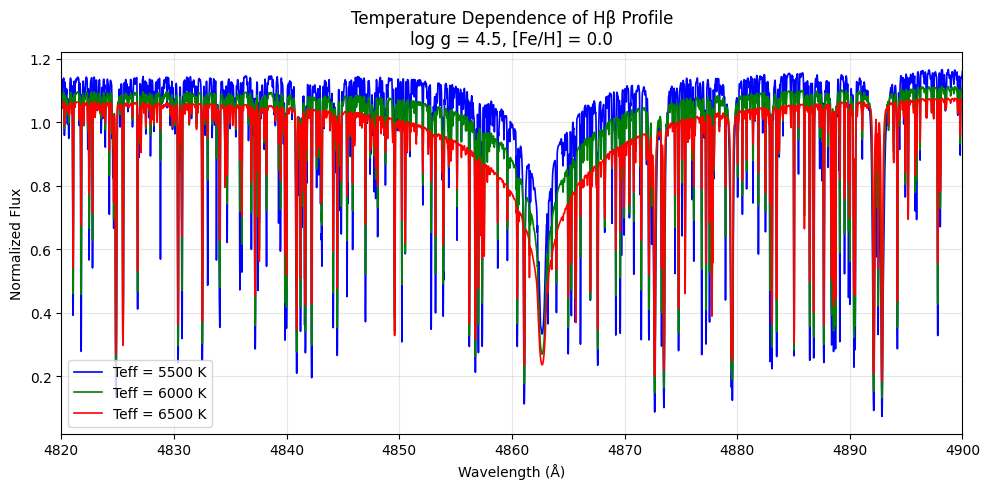

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))


colors = {
    5500: "blue",
    6000: "green",
    6500: "red"
}


for Teff in normalized_hbeta:

    plt.plot(
        wave_hbeta,
        normalized_hbeta[Teff],
        color=colors[Teff],
        linewidth=1.2,
        label=f"Teff = {Teff} K"
    )


plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")

plt.title(
    "Temperature Dependence of Hβ Profile\n"
    "log g = 4.5, [Fe/H] = 0.0"
)

plt.legend()

plt.grid(alpha=0.3)

plt.xlim(4820,4900)

plt.tight_layout()

plt.show()

## Temperature Dependence of Hβ Line

The Hβ line strength changes with effective temperature because the population of hydrogen atoms in the excited n=2 state depends strongly on temperature.

In the comparison between Teff = 5500 K, 6000 K, and 6500 K (log g = 4.5, [Fe/H] = 0.0), the hotter model shows a deeper Hβ absorption feature.

As temperature increases, more hydrogen atoms are excited to the n=2 level, increasing the number of atoms capable of absorbing Hβ photons (transition n=2 → n=4). Therefore, the line becomes stronger.

The line width also increases moderately with temperature due to changes in atmospheric structure and hydrogen level populations. However, the dominant broadening mechanism in these solar-type atmospheres is pressure (Stark) broadening.

## Step 18 — Surface Gravity Dependence of Hβ Profile

To investigate the effect of surface gravity, three PHOENIX models are compared:

- log g = 3.5 dex
- log g = 4.0 dex
- log g = 4.5 dex

Fixed atmospheric parameters:

- Teff = 6000 K
- [Fe/H] = 0.0

The Hβ region (4820–4900 Å) is extracted and normalized for each model.

In [ ]:
# Step 18.1 — Load different surface gravity models

logg_models = {
    3.5: "lte06000-3.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    4.0: "lte06000-4.00-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits",
    4.5: "lte06000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
}


flux_logg = {}


for logg, filename in logg_models.items():

    file_path = raw_dir / filename

    flux_logg[logg] = fits.getdata(file_path)

    print(
        "log g =",
        logg,
        "loaded:",
        len(flux_logg[logg])
    )

log g = 3.5 loaded: 1569128
log g = 4.0 loaded: 1569128
log g = 4.5 loaded: 1569128


## Step 18.2 — Extract Hβ Region

The Hβ region is selected:

\[
4820 \leq \lambda \leq 4900 \AA
\]

for each surface gravity model.

In [ ]:
# Step 18.2 — Extract Hβ region

mask_hbeta_logg = (wave >= 4820) & (wave <= 4900)

wave_hbeta_logg = wave[mask_hbeta_logg]


flux_hbeta_logg = {}


for logg in flux_logg:

    flux_hbeta_logg[logg] = flux_logg[logg][mask_hbeta_logg]

    print(
        "log g =",
        logg,
        "points:",
        len(flux_hbeta_logg[logg])
    )


print("\nWavelength range:")
print(
    wave_hbeta_logg[0],
    "to",
    wave_hbeta_logg[-1],
    "Å"
)

log g = 3.5 points: 13333
log g = 4.0 points: 13333
log g = 4.5 points: 13333

Wavelength range:
4820.004 to 4899.996 Å


## Step 18.3 — Normalize Hβ Profiles for Different Surface Gravities

The local pseudo-continuum is fitted using the same continuum windows:

- 4750–4810 Å
- 4920–4950 Å

Each Hβ profile is divided by its fitted continuum to allow direct comparison of line width and shape.

In [ ]:
# Step 18.3 — Normalize gravity-dependent Hβ profiles

normalized_hbeta_logg = {}


# Continuum windows
cont_mask_logg = (
    ((wave >= 4750) & (wave <= 4810)) |
    ((wave >= 4920) & (wave <= 4950))
)


for logg in flux_logg:

    flux_full = flux_logg[logg]

    # Continuum region
    wave_cont = wave[cont_mask_logg]
    flux_cont = flux_full[cont_mask_logg]


    # Polynomial continuum fit
    coeff = np.polyfit(
        wave_cont,
        flux_cont,
        deg=2
    )


    continuum = np.polyval(
        coeff,
        wave_hbeta_logg
    )


    normalized_hbeta_logg[logg] = (
        flux_hbeta_logg[logg] /
        continuum
    )


    print(
        "log g =",
        logg,
        "normalized"
    )

log g = 3.5 normalized
log g = 4.0 normalized
log g = 4.5 normalized


## Step 18.4 — Surface Gravity Effect on Hβ Profile

The normalized Hβ profiles are compared for:

- log g = 3.5 dex
- log g = 4.0 dex
- log g = 4.5 dex

with fixed:

- Teff = 6000 K
- [Fe/H] = 0.0

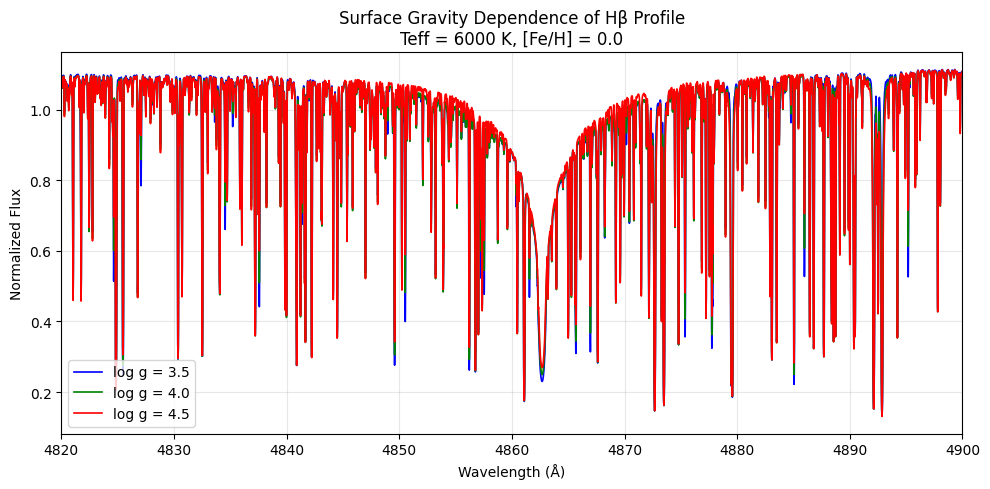

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))


colors = {
    3.5: "blue",
    4.0: "green",
    4.5: "red"
}


for logg in normalized_hbeta_logg:

    plt.plot(
        wave_hbeta_logg,
        normalized_hbeta_logg[logg],
        color=colors[logg],
        linewidth=1.2,
        label=f"log g = {logg}"
    )


plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")


plt.title(
    "Surface Gravity Dependence of Hβ Profile\n"
    "Teff = 6000 K, [Fe/H] = 0.0"
)


plt.legend()

plt.grid(alpha=0.3)

plt.xlim(4820,4900)

plt.tight_layout()

plt.show()

## Step 19 — Metallicity Dependence of Hβ Profile

To investigate the effect of metallicity, three PHOENIX spectra are compared:

- [Fe/H] = -0.5
- [Fe/H] = 0.0
- [Fe/H] = +0.5

Fixed atmospheric parameters:

- Teff = 5750 K
- log g = 4.5

The Hβ region (4820–4900 Å) is extracted and normalized.

## Step 19.1 — Required Models for Metallicity Comparison

The PHOENIX grid does not contain a direct Teff = 5750 K model.

Therefore, the 5750 K spectrum must be interpolated from:

- Teff = 5500 K
- Teff = 6000 K

For each metallicity:

- [Fe/H] = -0.5
- [Fe/H] = 0.0
- [Fe/H] = +0.5

with fixed:

- log g = 4.5

In [ ]:
# Step 19.1 — Check required interpolation files exist

required_files = []


for feh in [-0.5, 0.0, 0.5]:

    feh_string = format_feh_filename(feh)

    file_5500 = (
        raw_dir /
        f"lte05500-4.50{feh_string}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
    )

    file_6000 = (
        raw_dir /
        f"lte06000-4.50{feh_string}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
    )

    required_files.extend(
        [file_5500, file_6000]
    )


for file in required_files:

    print(
        file.name,
        "exists:",
        file.exists()
    )

lte05500-4.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits exists: True
lte06000-4.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits exists: True
lte05500-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits exists: True
lte06000-4.50-0.0.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits exists: True
lte05500-4.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits exists: True
lte06000-4.50+0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits exists: True


## Step 19.2 — Interpolate PHOENIX Models to Teff = 5750 K

The PHOENIX grid does not contain a model at Teff = 5750 K.

For each metallicity, the 5750 K spectrum is obtained by linear interpolation between:

- Teff = 5500 K
- Teff = 6000 K

at fixed:

- log g = 4.5

The interpolation is:

\[
F_{5750}=\frac{F_{5500}+F_{6000}}{2}
\]

In [ ]:
# Step 19.2 — Create interpolated 5750 K spectra

flux_5750_metal = {}

for feh in [-0.5, 0.0, 0.5]:

    feh_string = format_feh_filename(feh)

    file_5500 = (
        raw_dir /
        f"lte05500-4.50{feh_string}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
    )

    file_6000 = (
        raw_dir /
        f"lte06000-4.50{feh_string}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits"
    )


    flux_5500 = fits.getdata(file_5500)
    flux_6000 = fits.getdata(file_6000)


    flux_5750_metal[feh] = (
        flux_5500 + flux_6000
    ) / 2


    print(
        "[Fe/H] =",
        feh,
        "interpolated:",
        len(flux_5750_metal[feh])
    )

[Fe/H] = -0.5 interpolated: 1569128
[Fe/H] = 0.0 interpolated: 1569128
[Fe/H] = 0.5 interpolated: 1569128


## Step 19.3 — Extract Hβ Region for Different Metallicities

The Hβ region is extracted:

\[
4820 \leq \lambda \leq 4900 \AA
\]

for each interpolated Teff = 5750 K spectrum.

The extracted spectra will be used for normalization and comparison.

In [ ]:
# Step 19.3 — Extract Hβ region

mask_hbeta_metal = (
    (wave >= 4820) &
    (wave <= 4900)
)


wave_hbeta_metal = wave[mask_hbeta_metal]


flux_hbeta_metal = {}


for feh in flux_5750_metal:

    flux_hbeta_metal[feh] = (
        flux_5750_metal[feh][mask_hbeta_metal]
    )

    print(
        "[Fe/H] =",
        feh,
        "points:",
        len(flux_hbeta_metal[feh])
    )


print("\nWavelength range:")
print(
    wave_hbeta_metal[0],
    "to",
    wave_hbeta_metal[-1],
    "Å"
)

[Fe/H] = -0.5 points: 13333
[Fe/H] = 0.0 points: 13333
[Fe/H] = 0.5 points: 13333

Wavelength range:
4820.004 to 4899.996 Å


## Step 19.4 — Normalize Metallicity-dependent Hβ Profiles

The extracted Hβ spectra are normalized using the local pseudo-continuum.

The same continuum windows are used:

- 4750–4810 Å
- 4920–4950 Å

Normalization removes the continuum shape and allows comparison of spectral line changes caused by metallicity.

In [ ]:
# Step 19.4 — Continuum normalization for metallicity comparison

normalized_hbeta_metal = {}


# Continuum windows
cont_mask_metal = (
    ((wave >= 4750) & (wave <= 4810)) |
    ((wave >= 4920) & (wave <= 4950))
)


for feh in flux_5750_metal:

    # Full spectrum continuum points
    wave_cont = wave[cont_mask_metal]
    flux_cont = flux_5750_metal[feh][cont_mask_metal]


    # Polynomial continuum fit
    coeff = np.polyfit(
        wave_cont,
        flux_cont,
        deg=2
    )


    continuum = np.polyval(
        coeff,
        wave_hbeta_metal
    )


    normalized_hbeta_metal[feh] = (
        flux_hbeta_metal[feh] /
        continuum
    )


    print(
        "[Fe/H] =",
        feh,
        "normalized"
    )

[Fe/H] = -0.5 normalized
[Fe/H] = 0.0 normalized
[Fe/H] = 0.5 normalized


## Step 19.5 — Metallicity Effect on Hβ Profile

The normalized Hβ profiles are compared for:

- [Fe/H] = -0.5
- [Fe/H] = 0.0
- [Fe/H] = +0.5

Fixed parameters:

- Teff = 5750 K
- log g = 4.5

This comparison shows whether metallicity significantly changes the Hβ line profile.

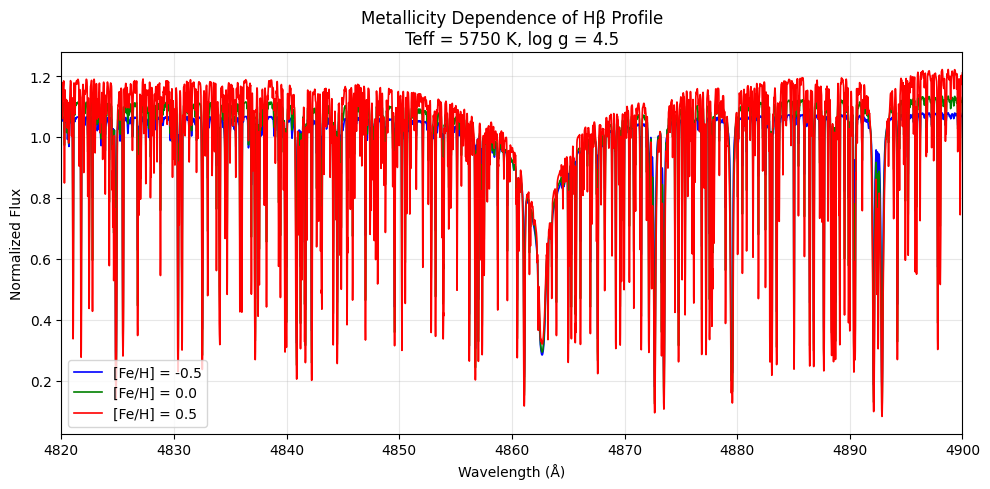

In [ ]:
# Step 19.5 — Plot metallicity comparison

import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))


colors = {
    -0.5: "blue",
     0.0: "green",
     0.5: "red"
}


for feh in normalized_hbeta_metal:

    plt.plot(
        wave_hbeta_metal,
        normalized_hbeta_metal[feh],
        color=colors[feh],
        linewidth=1.2,
        label=f"[Fe/H] = {feh}"
    )


plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")


plt.title(
    "Metallicity Dependence of Hβ Profile\n"
    "Teff = 5750 K, log g = 4.5"
)


plt.legend()

plt.grid(alpha=0.3)

plt.xlim(4820,4900)

plt.tight_layout()

plt.show()

## Metallicity Effect on the Hβ Line Profile

The comparison of the normalized Hβ profiles for different metallicities shows that the overall Hβ line shape and width remain nearly unchanged.

This is expected because Hβ is a hydrogen Balmer line and its strength is mainly controlled by the population of hydrogen atoms in the n=2 excited state, which depends strongly on temperature through the Boltzmann equation and on ionization balance through the Saha equation.

Changing metallicity mainly affects the abundance of heavy elements such as Fe, Ti, and other metals. Therefore, metal absorption features in the 4800–4900 Å region become stronger for higher metallicity and weaker for lower metallicity.

The Hβ profile itself is therefore much less sensitive to metallicity compared with metallic spectral features.

### Boltzmann and Saha Equations

The excitation population of hydrogen atoms is described by the Boltzmann equation:

$$
\frac{n_2}{n_1}
=
\frac{g_2}{g_1}
e^{-\frac{E_2-E_1}{kT}}
$$

The ionization balance is described by the Saha equation:

$$
\frac{n_{i+1}n_e}{n_i}
=
\frac{2U_{i+1}}{U_i}
\left(\frac{2\pi m_e kT}{h^2}\right)^{3/2}
e^{-\frac{\chi_i}{kT}}
$$

These equations show that hydrogen line formation depends mainly on temperature and electron density rather than metal abundance.

In [ ]:
%whos